In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

import scipy.interpolate as interp 
try:
    import cupy as xp
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
from scipy.signal import windows 

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.TDIFly import * 

import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

import multiprocessing
if __name__ == "__main__":
    multiprocessing.set_start_method("fork")

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 


## Settings 

In [2]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

## Initialize response models 

### TDI-on-the-fly, used as template for MLE 

In [3]:
X2_strings = TDIFly.X2_strings
Y2_strings = TDIStringManipulation.TDIStringCyc(X2_strings)
Z2_strings = TDIStringManipulation.TDIStringCyc(Y2_strings)

gb_tdifly_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring_list=[X2_strings, Y2_strings, Z2_strings], 
    tcb_times=tcb_times, 
    # Nsparse=1024, 
    Nsparse=512,
    # Nsparse=256,
    # drop_points=100, 
    use_gpu=False, 
)



### original polarization-based TDI response, used to inject test signal 

In [4]:
gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    # interp_method="linear", 
    # interp_method="Akima", 
    interp_method="Spline3",
)

## Specify GB source 

In [5]:
test_GB_parameters = {
    'A': 4.117951512530832e-23,
    'f0': 0.003271229550090303,
    'fdot0': 1.171144920010169e-16,
    'inclination': 0.6150624554322516,
    'phase0': 3.5370636366080825,
    'longitude': 4.893332732328381,
    'latitude': 0.22859823854063682,
    'psi': 0.38080181488222997
    }

### time-domain simulation (injection)

In [6]:
mich_aet_td = gb_response_generator(
    parameters=test_GB_parameters, 
    waveform_generator=gb_waveform_generator, 
    optimal_combination=True, 
    )

mich_a = np.fft.rfft(mich_aet_td[0]) * dt 
mich_e = np.fft.rfft(mich_aet_td[1]) * dt 
freqs = np.fft.rfftfreq(n=mich_aet_td.shape[-1], d=dt)

# cut_freq_range = 5e-5 
cut_freq_range = 5e-6 # should be enough for this source 
cut_freq_idx = np.where(np.abs(freqs-test_GB_parameters["f0"])<cut_freq_range)[0]
freqs = freqs[cut_freq_idx]
mich_ae = np.array([
    mich_a[cut_freq_idx], 
    mich_e[cut_freq_idx], 
])

mich_ae.shape # (Nchannel, Nfreq)

(2, 315)

### Add Gaussian noise to the frequency-domain data within the target bin

In [7]:
# DDDD
PSDfunc = TDIPSDs()
PSD_ae = np.array([PSDfunc.PSD_A2(freqs), PSDfunc.PSD_A2(freqs)]) # shape: (2, Nf) use the same noise profile for AE
Re_tmp = xp.random.normal(scale=xp.sqrt(PSD_ae / 4. * Tobs))
Im_tmp = xp.random.normal(scale=xp.sqrt(PSD_ae / 4. * Tobs))
noise_ae = Re_tmp + 1.j * Im_tmp 

mich_ae += noise_ae
noise_ae.shape 

(2, 315)

### frequency-domain model (template)

In [8]:
fly_xyz = gb_tdifly_generator(
    parameters=test_GB_parameters, 
    domain="frequency"
    )
fly_aet = AETfromXYZ(fly_xyz[0], fly_xyz[1], fly_xyz[2])
fly_ae_valid = np.array([fly_aet[0], fly_aet[1]])


fly_ae = gb_tdifly_generator.fill_fftseries(
    data=fly_ae_valid, 
    start_idx=gb_tdifly_generator.start_idx, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1],
)

fly_ae.shape # (Nchannel, Nevent, Nfreq)

(2, 1, 315)

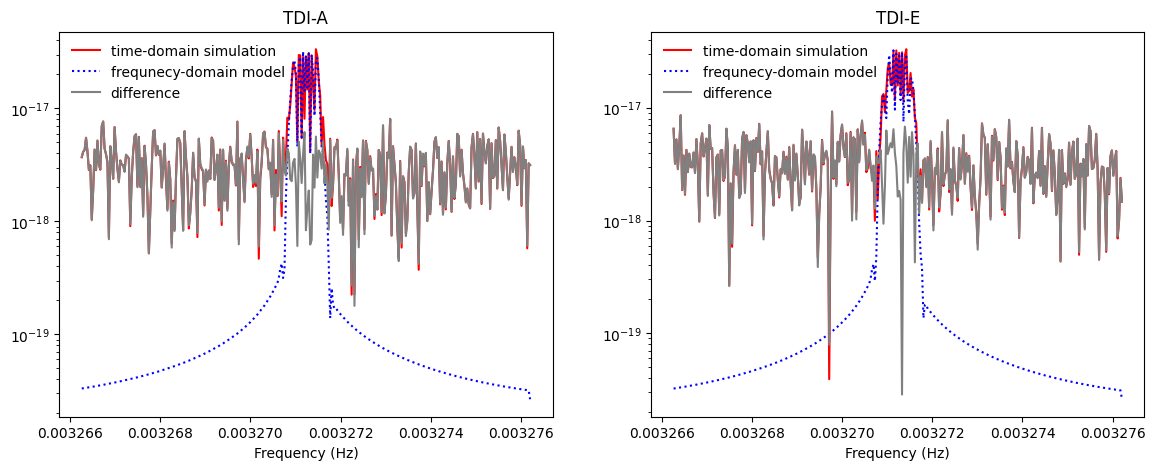

In [9]:
plt.figure(figsize=(14, 5))
for ichannel, nchannel in enumerate(["A", "E"]):
    plt.subplot(121+ichannel)
    plt.semilogy(freqs, np.abs(mich_ae[ichannel]), color="r", label="time-domain simulation")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0]), linestyle=":", color="b", label="frequnecy-domain model")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0] - mich_ae[ichannel]), linestyle="-", color="grey", label="difference")
    plt.legend(frameon=False, loc="upper left")

    plt.xlabel("Frequency (Hz)")
    plt.title("TDI-"+nchannel)

In [10]:
print("template SNR:", gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs))
print("data SNR:", gb_tdifly_generator.SNR(mich_ae[:, xp.newaxis, :], test_GB_parameters["f0"], Tobs))
print("residual SNR:", gb_tdifly_generator.SNR(fly_ae - mich_ae[:, xp.newaxis,:], test_GB_parameters["f0"], Tobs))
print("mismatch:", gb_tdifly_generator.mismatch(h1=mich_ae, h2=fly_ae))
print("mismatch threshold:", 2. * 8. / gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs) ** 2)

template SNR: [54.37721887]
data SNR: [65.48910117]
residual SNR: [35.52393741]
mismatch: [0.15984827]
mismatch threshold: [0.00541111]


## Test GB MLE search 

In [11]:
f_min, f_max = 0.003266229550090303, 0.0032762295500903026 # 1e-5 Hz band containing the source frequency 
intrinsic_param_priors = np.array([
    [f_min, f_max], # f0
    [0., TDIFlyGB.fdot_upper_bound(f_min)], # fdot0 
    [0, TWOPI], # longitude 
    [-1., 1.] # sin latitude 
])
intrinsic_param_priors

array([[ 3.26622955e-03,  3.27622955e-03],
       [ 0.00000000e+00,  7.67075149e-16],
       [ 0.00000000e+00,  6.28318531e+00],
       [-1.00000000e+00,  1.00000000e+00]])

In [12]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
    params_in = TDIFlyGB.IntParamArr2Dict(int_params) # (Nparams) -> dictionary
    return -gb_tdifly_generator.Fstatistics(
        data=mich_ae, 
        intrinsic_parameters=params_in, 
        StartBound=cut_freq_idx[0], 
        EndBound=cut_freq_idx[-1], 
        Tobs=Tobs, 
        S=gb_tdifly_generator.PSD_A2(f=f_min), 
        )[0] 

n_dim_int = 4
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    # strategy='rand1bin',
    maxiter=5000,
    popsize=5*n_dim_int, 
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    # vectorized=True,
    workers=-1, 
)

print(DE_result)

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -1524.236566941645
                   x: [ 5.002e-01  3.069e-06  7.799e-01  6.221e-01]
                 nit: 104
                nfev: 8400
          population: [[ 5.002e-01  3.069e-06  7.799e-01  6.221e-01]
                       [ 5.002e-01  1.269e-06  7.799e-01  6.220e-01]
                       ...
                       [ 5.002e-01  2.872e-05  7.798e-01  6.221e-01]
                       [ 5.002e-01  3.680e-04  7.799e-01  6.220e-01]]
 population_energies: [-1.524e+03 -1.524e+03 ... -1.524e+03 -1.524e+03]


### recover extrinsic parameters and waveform using the searched intrinsic parameters 

In [13]:
searched_int_params = TDIFlyGB.IntParamArr2Dict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=searched_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=f_min), 
    return_a=True, 
)
searched_ext_params = TDIFlyGB.a_to_extrinsic(searched_a)

searched_params = dict(searched_int_params, **searched_ext_params)

print("parameter name | truth value | searched value | difference")
for k, v in searched_params.items(): 
    print(k, test_GB_parameters[k], v, np.abs(v-test_GB_parameters[k])) # sometimes psi and phase would not perfectly match since they are multi-model, while the waveform can always be correctly recovered

parameter name | truth value | searched value | difference
f0 0.003271229550090303 0.003271231305004013 1.7549137100100753e-09
fdot0 1.171144920010169e-16 2.3543094097173233e-21 1.171121376916072e-16
longitude 4.893332732328381 4.900005335451375 0.006672603122994225
latitude 0.22859823854063682 0.24662799148087297 0.01802975294023615
A 4.117951512530832e-23 4.6565684527690536e-23 5.386169402382219e-24
inclination 0.6150624554322516 0.7687891831805367 0.1537267277482851
psi 0.38080181488222997 0.9985760350089818 0.6177742201267519
phase0 3.5370636366080825 2.2545710924511306 1.282492544156952


In [14]:
# searched_wf = gb_tdifly_generator.Fstatistics(
#     data=mich_ae, 
#     intrinsic_parameters=searched_int_params, 
#     StartBound=cut_freq_idx[0], 
#     EndBound=cut_freq_idx[-1], 
#     Tobs=Tobs, 
#     S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
#     return_recovered_wave=True, 
# )

# searched_wf.shape

searched_xyz = gb_tdifly_generator(
    parameters=searched_params, 
    domain="frequency"
    )
searched_aet = AETfromXYZ(searched_xyz[0], searched_xyz[1], searched_xyz[2])
searched_ae_valid = np.array([searched_aet[0], searched_aet[1]])

searched_wf = gb_tdifly_generator.fill_fftseries(
    data=searched_ae_valid, 
    start_idx=gb_tdifly_generator.start_idx, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1],
)

searched_wf.shape # (Nchannel, Nevent, Nfreq)

(2, 1, 315)

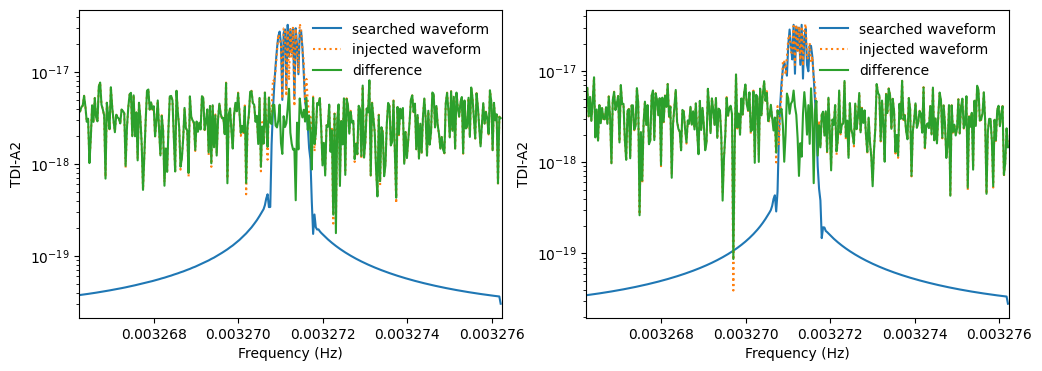

In [15]:
plt.figure(figsize=(12,4))
for i in range(2):
    plt.subplot(121+i)
    plt.semilogy(freqs, np.abs(searched_wf[i][0]), label="searched waveform")
    plt.semilogy(freqs, np.abs(mich_ae[i]), linestyle=":", label="injected waveform")
    plt.semilogy(freqs, np.abs(searched_wf[i][0] - mich_ae[i]), label="difference")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("TDI-A2")
    plt.legend(loc="upper right", frameon=False)
    plt.xlim(intrinsic_param_priors[0][0], intrinsic_param_priors[0][1])
    # plt.ylim(1e-19,)